<a href="https://colab.research.google.com/github/harshsalvi1810/PythonProgramming/blob/main/Pandas_L2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    'Name':['A','B','C','D','E','F'],
    'Department':['HR','IT','SALES','HR','IT','SALES'],
    'Age':[28,46,25,46,39,50],
    'Salary':[5000,4000,6000,3000,8000,9000],
    'Experience_years':[5,3,4,9,6,2]
})

In [ ]:
df

,Name,Department,Age,Salary,Experience_years
0,A,HR,28,5000,5
1,B,IT,46,4000,3
2,C,SALES,25,6000,4
3,D,HR,46,3000,9
4,E,IT,39,8000,6
5,F,SALES,50,9000,2


In [ ]:
# Discriptive Stats
from collections import OrderedDict

stats = []

for i in df.select_dtypes(exclude = 'object'):
    numerical_stats = OrderedDict({
        'Feature':i,
        'Count':df[i].count(),
        'Maximum':df[i].max(),
        'Minimum':df[i].min(),
        'Mean':df[i].mean(),
        'Median':df[i].median(),
        'Q1':df[i].quantile(0.25),
        'Q3':df[i].quantile(0.75),
        'IQR':df[i].quantile(0.75) - df[i].quantile(0.25),
        'LW':df[i].quantile(0.25) - 1.5*(df[i].quantile(0.75) - df[i].quantile(0.25)),
        'UW':df[i].quantile(0.75) + 1.5*(df[i].quantile(0.75) - df[i].quantile(0.25)),
        'Standard_deviation':df[i].std(),
        'Skewness':df[i].skew(),
        'Kurtosis':df[i].kurt()
    })
    stats.append(numerical_stats)
    report = pd.DataFrame(stats)
report.T


,0,1,2
Feature,Age,Salary,Experience_years
Count,6,6,6
Maximum,50,9000,9
Minimum,25,3000,2
Mean,39.0,5833.333333,4.833333
Median,42.5,5500.0,4.5
Q1,30.75,4250.0,3.25
Q3,46.0,7500.0,5.75
IQR,15.25,3250.0,2.5
LW,7.875,-625.0,-0.5


In [ ]:
df = pd.DataFrame({
    'Name':['A','B','C',np.nan,'E',np.nan],
    'Department':['HR','IT',np.nan,'HR',np.nan,'SALES'],
    'Age':[28,np.nan,25,46,np.nan,50],
    'Salary':[5000,np.nan,6000,np.nan,8000,9000],
    'Experience_years':[5,3,4,9,6,2]
})
df.isnull().sum()

,0
Name,2
Department,2
Age,2
Salary,2
Experience_years,0


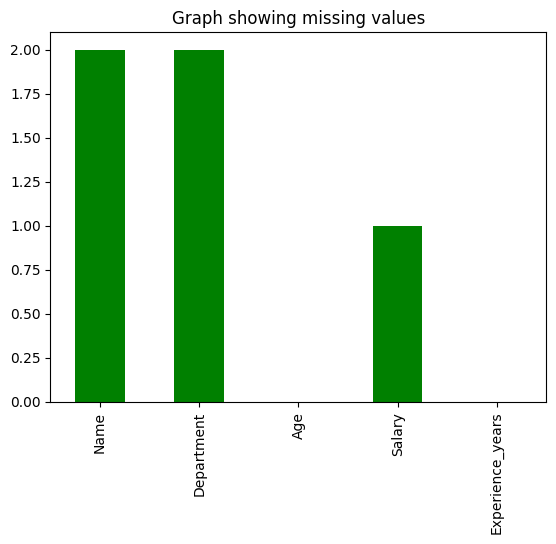

In [ ]:
import matplotlib.pyplot as plt
df.isnull().sum().plot(kind = 'bar',color = 'green')
plt.title('Graph showing missing values')
plt.show()

In [ ]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df

,Name,Department,Age,Salary,Experience_years
0,A,HR,28.0,5000.0,5
1,B,IT,NaN,7000.0,3
2,C,NaN,25.0,6000.0,4
3,NaN,HR,46.0,7000.0,9
4,E,NaN,NaN,8000.0,6
5,NaN,SALES,50.0,9000.0,2


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df

,Name,Department,Age,Salary,Experience_years
0,A,HR,28.00,5000.0,5
1,B,IT,37.25,7000.0,3
2,C,HR,25.00,6000.0,4
3,A,HR,46.00,7000.0,9
4,E,HR,37.25,8000.0,6
5,A,SALES,50.00,9000.0,2


In [ ]:
df['Name'] = df['Name'].fillna(df['Name'].mode()[0])
df

,Name,Department,Age,Salary,Experience_years
0,A,HR,28.00,5000.0,5
1,B,IT,37.25,7000.0,3
2,C,NaN,25.00,6000.0,4
3,A,HR,46.00,7000.0,9
4,E,NaN,37.25,8000.0,6
5,A,SALES,50.00,9000.0,2


In [ ]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df

,Name,Department,Age,Salary,Experience_years
0,A,HR,28.00,5000.0,5
1,B,IT,37.25,7000.0,3
2,C,HR,25.00,6000.0,4
3,A,HR,46.00,7000.0,9
4,E,HR,37.25,8000.0,6
5,A,SALES,50.00,9000.0,2


In [ ]:
employee_data = {
    'Employee_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name': ['Amit', 'Priya', 'Rahul', 'Sneha', 'Karan', 'Neha', 'Vijay', 'Pooja', 'Rohit', 'Anjali'],
    'Age': [25, 30, np.nan, 28, 35, np.nan, 40, 29, 31, 27],
    'Department': ['HR', 'IT', 'Finance', np.nan, 'IT', 'HR', 'Finance', 'Marketing', np.nan, 'IT'],
    'Salary': [45000, 60000, 55000, np.nan, 70000, 48000, np.nan, 52000, 61000, 58000],
    'Experience': [2, 5, 4, 3, np.nan, 2, 10, 4, 6, np.nan],
    'Performance_Rating': [4.5, 4.8, np.nan, 4.2, 4.9, 4.1, 5.0, np.nan, 4.6, 4.3]
}


df = pd.DataFrame(employee_data)

df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.5
1,102,Priya,30.0,IT,60000.0,5.0,4.8
2,103,Rahul,NaN,Finance,55000.0,4.0,NaN
3,104,Sneha,28.0,NaN,NaN,3.0,4.2
4,105,Karan,35.0,IT,70000.0,NaN,4.9
5,106,Neha,NaN,HR,48000.0,2.0,4.1
6,107,Vijay,40.0,Finance,NaN,10.0,5.0
7,108,Pooja,29.0,Marketing,52000.0,4.0,NaN
8,109,Rohit,31.0,NaN,61000.0,6.0,4.6
9,110,Anjali,27.0,IT,58000.0,NaN,4.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         10 non-null     int64  
 1   Name                10 non-null     object 
 2   Age                 8 non-null      float64
 3   Department          8 non-null      object 
 4   Salary              8 non-null      float64
 5   Experience          8 non-null      float64
 6   Performance_Rating  8 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 692.0+ bytes


In [ ]:
from collections import OrderedDict

stats = []

for i in df.select_dtypes(exclude = 'object'):
    numerical_stats = OrderedDict({
    'feature':[i],
    'Count':df[i].count(),
    'Maximum':df[i].max(),
    'Minimum':df[i].min(),
    'Mean':df[i].mean(),
    'Median':df[i].median(),
    'Q1':df[i].quantile(0.25),
    'Q3':df[i].quantile(0.75),
    'IQR':df[i].quantile(0.75) - df[i].quantile(0.25),
    'LW':df[i].quantile(0.25) - 1.5*(df[i].quantile(0.75) - df[i].quantile(0.25)),
    'UW':df[i].quantile(0.75) + 1.5*(df[i].quantile(0.75) - df[i].quantile(0.25)),
    'Standard_deviation':df[i].std(),
    'Skewness':df[i].skew(),
    'Kurtosis':df[i].kurt()
})
    stats.append(numerical_stats)
    report = pd.DataFrame(stats)
report.T

,0,1,2,3,4
feature,[Employee_ID],[Age],[Salary],[Experience],[Performance_Rating]
Count,10,8,8,8,8
Maximum,110.0,40.0,70000.0,10.0,5.0
Minimum,101.0,25.0,45000.0,2.0,4.1
Mean,105.5,30.625,56125.0,4.5,4.55
Median,105.5,29.5,56500.0,4.0,4.55
Q1,103.25,27.75,51000.0,2.75,4.275
Q3,107.75,32.0,60250.0,5.25,4.825
IQR,4.5,4.25,9250.0,2.5,0.55
LW,96.5,21.375,37125.0,-1.0,3.45


In [ ]:
from collections import OrderedDict

cat_stats = []

for i in df.select_dtypes(include = 'object'):
    categorical_stats = OrderedDict({
    'feature':[i],
    'Count':df[i].count(),
    'Mode':df[i].mode()[0],
})
    cat_stats.append(categorical_stats)
    cat_report = pd.DataFrame(cat_stats)
cat_report

,feature,Count,Mode
0,[Name],10,Amit
1,[Department],8,IT


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Name,0
Age,2
Department,2
Salary,2
Experience,2
Performance_Rating,2


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.5
1,102,Priya,30.0,IT,60000.0,5.0,4.8
2,103,Rahul,29.5,Finance,55000.0,4.0,NaN
3,104,Sneha,28.0,NaN,NaN,3.0,4.2
4,105,Karan,35.0,IT,70000.0,NaN,4.9
5,106,Neha,29.5,HR,48000.0,2.0,4.1
6,107,Vijay,40.0,Finance,NaN,10.0,5.0
7,108,Pooja,29.0,Marketing,52000.0,4.0,NaN
8,109,Rohit,31.0,NaN,61000.0,6.0,4.6
9,110,Anjali,27.0,IT,58000.0,NaN,4.3


In [ ]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.5
1,102,Priya,30.0,IT,60000.0,5.0,4.8
2,103,Rahul,29.5,Finance,55000.0,4.0,NaN
3,104,Sneha,28.0,NaN,56500.0,3.0,4.2
4,105,Karan,35.0,IT,70000.0,NaN,4.9
5,106,Neha,29.5,HR,48000.0,2.0,4.1
6,107,Vijay,40.0,Finance,56500.0,10.0,5.0
7,108,Pooja,29.0,Marketing,52000.0,4.0,NaN
8,109,Rohit,31.0,NaN,61000.0,6.0,4.6
9,110,Anjali,27.0,IT,58000.0,NaN,4.3


In [ ]:
df['Experience'] = df['Experience'].fillna(df['Experience'].median())
df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.5
1,102,Priya,30.0,IT,60000.0,5.0,4.8
2,103,Rahul,29.5,Finance,55000.0,4.0,NaN
3,104,Sneha,28.0,NaN,56500.0,3.0,4.2
4,105,Karan,35.0,IT,70000.0,4.0,4.9
5,106,Neha,29.5,HR,48000.0,2.0,4.1
6,107,Vijay,40.0,Finance,56500.0,10.0,5.0
7,108,Pooja,29.0,Marketing,52000.0,4.0,NaN
8,109,Rohit,31.0,NaN,61000.0,6.0,4.6
9,110,Anjali,27.0,IT,58000.0,4.0,4.3


In [ ]:
df['Performance_Rating'] = df['Performance_Rating'].fillna(df['Performance_Rating'].median())
df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.50
1,102,Priya,30.0,IT,60000.0,5.0,4.80
2,103,Rahul,29.5,Finance,55000.0,4.0,4.55
3,104,Sneha,28.0,NaN,56500.0,3.0,4.20
4,105,Karan,35.0,IT,70000.0,4.0,4.90
5,106,Neha,29.5,HR,48000.0,2.0,4.10
6,107,Vijay,40.0,Finance,56500.0,10.0,5.00
7,108,Pooja,29.0,Marketing,52000.0,4.0,4.55
8,109,Rohit,31.0,NaN,61000.0,6.0,4.60
9,110,Anjali,27.0,IT,58000.0,4.0,4.30


In [ ]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.50
1,102,Priya,30.0,IT,60000.0,5.0,4.80
2,103,Rahul,29.5,Finance,55000.0,4.0,4.55
3,104,Sneha,28.0,IT,56500.0,3.0,4.20
4,105,Karan,35.0,IT,70000.0,4.0,4.90
5,106,Neha,29.5,HR,48000.0,2.0,4.10
6,107,Vijay,40.0,Finance,56500.0,10.0,5.00
7,108,Pooja,29.0,Marketing,52000.0,4.0,4.55
8,109,Rohit,31.0,IT,61000.0,6.0,4.60
9,110,Anjali,27.0,IT,58000.0,4.0,4.30


In [ ]:
HR = df[df['Department'] == 'HR']
HR

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
0,101,Amit,25.0,HR,45000.0,2.0,4.5
5,106,Neha,29.5,HR,48000.0,2.0,4.1


In [ ]:
IT = df[df['Department'] == 'IT']
IT

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
1,102,Priya,30.0,IT,60000.0,5.0,4.8
3,104,Sneha,28.0,IT,56500.0,3.0,4.2
4,105,Karan,35.0,IT,70000.0,4.0,4.9
8,109,Rohit,31.0,IT,61000.0,6.0,4.6
9,110,Anjali,27.0,IT,58000.0,4.0,4.3


In [ ]:
Finance = df[df['Department'] == 'Finance']
Finance

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
2,103,Rahul,29.5,Finance,55000.0,4.0,4.55
6,107,Vijay,40.0,Finance,56500.0,10.0,5.00


In [ ]:
Marketing = df[df['Department'] == 'Marketing']
Marketing

,Employee_ID,Name,Age,Department,Salary,Experience,Performance_Rating
7,108,Pooja,29.0,Marketing,52000.0,4.0,4.55
